In [1]:
import os, cv2
import numpy as np

LOCAL_SHOP    = '/kaggle/input/datasets/saharamrr/dataset/DataSet/shop_lifters'
LOCAL_NONSHOP = '/kaggle/input/datasets/saharamrr/dataset/DataSet/non_shop_lifters'

print(f'shop={len(os.listdir(LOCAL_SHOP))}  non-shop={len(os.listdir(LOCAL_NONSHOP))}')

shop=324  non-shop=531


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, MaxPooling2D, BatchNormalization,
    TimeDistributed, GlobalAveragePooling2D, AveragePooling2D,
    LSTM, Bidirectional, Dense, Dropout, LayerNormalization,
    Multiply, Reshape, Permute, Lambda, Activation, Add,
    MultiHeadAttention, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

2026-03-19 06:01:21.316128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773900081.543979      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773900081.611122      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773900082.123267      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773900082.123306      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773900082.123309      55 computation_placer.cc:177] computation placer alr

In [3]:

IMG_SIZE    = 112          
N_FRAMES    = 20           # more frames → better temporal coverage
BATCH_SIZE  = 8
EPOCHS      = 60
SEED        = 42
SAVE_PATH   = '/kaggle/working/shoplifting_best.keras'
N_CHANNELS  = 4  # RGB(3) + motion-diff(1)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
# 4. LOAD LABELS
# Build video_paths + labels directly from folder structure
# Class 0 = non_shop_lifters | Class 1 = shop_lifters

video_paths, label_list = [], []

for fname in sorted(os.listdir(LOCAL_NONSHOP)):
    if fname.endswith('.mp4'):
        video_paths.append(os.path.join(LOCAL_NONSHOP, fname))
        label_list.append(0)

for fname in sorted(os.listdir(LOCAL_SHOP)):
    if fname.endswith('.mp4'):
        video_paths.append(os.path.join(LOCAL_SHOP, fname))
        label_list.append(1)

labels = np.array(label_list)
print(f'Videos found : {len(video_paths)}')
print(f'Class 0 (Normal): {np.sum(labels==0)} | Class 1 (Shoplifting): {np.sum(labels==1)}')




Videos found : 855
Class 0 (Normal): 531 | Class 1 (Shoplifting): 324


In [5]:
# 5. AUGMENTATION HELPER

def augment_video(frames):
    """
    Manual augmentation — same transform applied to all frames.
    Pure numpy/cv2: no ImageDataGenerator quirks.
    Input/output: float32 in [0, 1], shape (N, H, W, 4)
    """
    H, W = frames.shape[1], frames.shape[2]

    # ── Decide transforms once for the whole clip ──
    do_flip       = np.random.rand() < 0.5
    angle         = np.random.uniform(-8, 8)
    brightness    = np.random.uniform(0.88, 1.12)
    tx            = np.random.uniform(-0.05, 0.05) * W   # width shift
    ty            = np.random.uniform(-0.05, 0.05) * H   # height shift
    zoom          = np.random.uniform(0.95, 1.05)

    # Build affine matrix (rotation + shift + zoom)
    cx, cy = W / 2, H / 2
    M_rot  = cv2.getRotationMatrix2D((cx, cy), angle, zoom)
    M_rot[0, 2] += tx
    M_rot[1, 2] += ty

    out = []
    for f in frames:
        rgb = f[:, :, :3].copy()   # transform RGB only
        if do_flip:
            rgb = rgb[:, ::-1, :]
        rgb = cv2.warpAffine(rgb, M_rot, (W, H),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT_101)
        rgb = np.clip(rgb * brightness, 0.0, 1.0)
        out.append(rgb)

    rgb_stack = np.array(out, dtype=np.float32)       # (N, H, W, 3)
    # Recompute motion after spatial transform
    gray = rgb_stack.mean(axis=-1, keepdims=True)
    diff = np.zeros_like(gray)
    diff[1:] = np.abs(gray[1:] - gray[:-1])
    diff = np.clip(diff * 3.0, 0.0, 1.0)
    return np.concatenate([rgb_stack, diff], axis=-1)  # (N, H, W, 4)




In [6]:
# 6. DATA GENERATOR  (defined ONCE — fixed bug)

class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=BATCH_SIZE,
                 augment=False, shuffle=True, **kw):
        super().__init__(**kw)
        self.paths      = list(paths)
        self.labels     = list(labels)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indexes    = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def _load_frames(self, path):
        """
        Load N_FRAMES uniformly sampled from video.
        Uses decord (primary) -> cv2 (fallback).
        decord is far more reliable in Colab for full video decoding.
        """
        blank = np.zeros((IMG_SIZE, IMG_SIZE, 4), dtype=np.float32)

        # Primary: decord
        try:
            from decord import VideoReader, cpu
            vr     = VideoReader(path, ctx=cpu(0))
            total  = len(vr)
            if total == 0:
                raise ValueError('empty video')
            indices = np.linspace(0, total - 1, N_FRAMES, dtype=int)
            frames  = vr.get_batch(indices).asnumpy()  # (N, H, W, 3) uint8 RGB
            if frames.shape[1] != IMG_SIZE or frames.shape[2] != IMG_SIZE:
                frames = np.array([
                    cv2.resize(f, (IMG_SIZE, IMG_SIZE)) for f in frames
                ], dtype=np.uint8)
            rgb = frames.astype(np.float32) / 255.0
            return self._add_motion_channel(rgb)

        except Exception:
            pass  # fall through to cv2

        # Fallback: cv2
        try:
            cap     = cv2.VideoCapture(path)
            all_raw = []
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_raw.append(frame)
            cap.release()

            if len(all_raw) == 0:
                return np.array([blank] * N_FRAMES, dtype=np.float32)

            indices = np.linspace(0, len(all_raw) - 1, N_FRAMES, dtype=int)
            rgb = np.array([all_raw[i] for i in indices], dtype=np.float32) / 255.0
            return self._add_motion_channel(rgb)

        except Exception:
            return np.zeros((N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), dtype=np.float32)


    def _add_motion_channel(self, rgb):
        """
        rgb: (N, H, W, 3) float32 [0,1]
        returns: (N, H, W, 4) — RGB + amplified frame-difference (motion)
        """
        gray = rgb.mean(axis=-1, keepdims=True)       # (N, H, W, 1)
        diff = np.zeros_like(gray)
        diff[1:] = np.abs(gray[1:] - gray[:-1])
        diff = np.clip(diff * 3.0, 0.0, 1.0)
        return np.concatenate([rgb, diff], axis=-1)   # (N, H, W, 4)

    def __getitem__(self, idx):
        bi = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for i in bi:
            frames = self._load_frames(self.paths[i])
            if self.augment:
                frames = augment_video(frames)
            X.append(frames)
            y.append(self.labels[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)




In [7]:
# 7. CLEAN BAD VIDEOS + SPLIT

# scan all videos for readability issues 

bad_videos = []
for p in video_paths:
    cap = cv2.VideoCapture(p)
    ret, frame = cap.read()
    cap.release()
    if not ret or frame is None or frame.mean() <= 1.0:
        bad_videos.append(p)

if bad_videos:
    print(f'{len(bad_videos)} unreadable videos found — removing from dataset')
    bad_set = set(bad_videos)
    clean   = [(p, l) for p, l in zip(video_paths, labels.tolist()) if p not in bad_set]
    video_paths, labels = zip(*clean)
    video_paths = list(video_paths)
    labels      = np.array(labels)
    print(f'Remaining: {len(video_paths)} videos')
else:
    print(f'All {len(video_paths)} videos readable ')

# Re-split after cleaning
tv, test_v, tl, test_l = train_test_split(
    video_paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
tv, val_v, tl, val_l = train_test_split(
    tv, tl, test_size=0.20, stratify=tl, random_state=SEED)

train_gen = VideoDataGenerator(tv,     tl,     augment=True,  shuffle=True)
val_gen   = VideoDataGenerator(val_v,  val_l,  augment=False, shuffle=False)
test_gen  = VideoDataGenerator(test_v, test_l, augment=False, shuffle=False)
print(f'Train={len(tv)} | Val={len(val_v)} | Test={len(test_v)}')
print(f'Class 0: {np.sum(np.array(tl)==0)} | Class 1: {np.sum(np.array(tl)==1)} ')

# Quick sanity check
X_s, y_s = train_gen[0]
print(f'\nBatch shape : {X_s.shape}')
print(f'Mean pixel  : {X_s.mean():.4f}')
assert X_s.shape == (BATCH_SIZE, N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), \
    f'Wrong shape: {X_s.shape}'
assert X_s.mean() > 0.01, \
    f'Still black frames! mean={X_s.mean():.5f} — codec issue, try: pip install opencv-python-headless'

All 855 videos readable 
Train=580 | Val=146 | Test=129
Class 0: 360 | Class 1: 220 

Batch shape : (8, 20, 112, 112, 4)
Mean pixel  : 0.3593


In [8]:
# 8. MODEL — Lightweight CNN-BiLSTM
#    Sized for 432 training samples (~450K params)
#    NO pretrained weights

def build_frame_cnn():
    """
    3-block lightweight CNN.
    Output: 128-dim vector per frame.
    Kept small to avoid overfitting on 432 samples.
    """
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS))  # 4ch: RGB + motion

    # Block 1 — edges, texture & motion
    x = Conv2D(16, 3, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # 56x56

    # Block 2
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # 28x28

    # Block 3
    x = Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # 14x14

    x = GlobalAveragePooling2D()(x)         # (64,)
    x = Dense(128, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)

    return Model(inp, x, name='frame_cnn')


def build_model():
    vid_input = Input(shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), name='video')

    # Per-frame features
    frame_cnn = build_frame_cnn()
    x = TimeDistributed(frame_cnn, name='td_cnn')(vid_input)   # (B, T, 128)
    x = LayerNormalization()(x)

    # Single BiLSTM — no recurrent_dropout (causes instability in Keras 3)
    x = Bidirectional(
        LSTM(64, return_sequences=False, dropout=0.4)
    )(x)                                                        # (B, 128)

    # Classifier
    x = Dense(64, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    return Model(vid_input, out, name='ShopliftingDetector')

In [9]:
# 10. COMPILE & TRAIN

tf.keras.backend.clear_session()
model = build_model()

model.compile(
    optimizer=Adam(learning_rate=3e-5, clipnorm=1.0),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()
print(f'\nTotal params: {model.count_params():,}')

# Callbacks — defined ONCE, used ONCE
callbacks = [
    ModelCheckpoint(
        SAVE_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', patience=12,
        restore_best_weights=True, mode='max', verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=5, min_lr=1e-7, mode='max', verbose=1
    )
]

# Classes are balanced — no class_weight needed
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)




I0000 00:00:1773900128.447442      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773900128.453461      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ShopliftingDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video (InputLayer)              │ (None, 20, 112, 112,   │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_cnn (TimeDistributed)        │ (None, 20, 128)        │        41,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 20, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,121 (582.50 KB)

 Trainable params: 148,833 (581.38 KB)

 Non-trainable params: 288 (1.12 KB)


Total params: 149,121
Epoch 1/60


I0000 00:00:1773900157.506131    3579 cuda_dnn.cc:529] Loaded cuDNN version 91002


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4345 - auc: 0.5163 - loss: 0.7602 - precision: 0.3702 - recall: 0.7387
Epoch 1: val_auc improved from -inf to 0.63656, saving model to /kaggle/working/shoplifting_best.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.4351 - auc: 0.5164 - loss: 0.7600 - precision: 0.3705 - recall: 0.7385 - val_accuracy: 0.6233 - val_auc: 0.6366 - val_loss: 0.6946 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-05
Epoch 2/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5745 - auc: 0.5933 - loss: 0.6923 - precision: 0.4368 - recall: 0.5567
Epoch 2: val_auc did not improve from 0.63656
73/73 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.5744 - auc: 0.5930 - loss: 0.6923 - precision: 0.4368 - recall: 0.5558 - val_accuracy: 0.6233 - val_auc: 0.6351 - val_loss: 0.6768 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-05
Epoch 3/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0


 Validation Set 
              precision    recall  f1-score   support

      Normal       0.78      0.76      0.77        91
 Shoplifting       0.61      0.64      0.62        55

    accuracy                           0.71       146
   macro avg       0.69      0.70      0.70       146
weighted avg       0.71      0.71      0.71       146

ROC-AUC: 0.7952


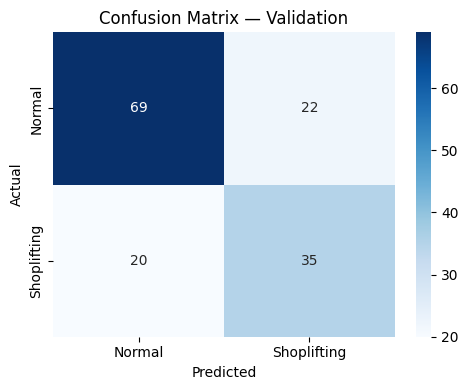


 Test Set 
              precision    recall  f1-score   support

      Normal       0.78      0.71      0.75        80
 Shoplifting       0.59      0.67      0.63        49

    accuracy                           0.70       129
   macro avg       0.69      0.69      0.69       129
weighted avg       0.71      0.70      0.70       129

ROC-AUC: 0.7918


In [10]:
# 11. EVALUATION

print('\n Validation Set ')
y_true_val  = val_l
y_prob_val  = model.predict(val_gen, verbose=0).ravel()
y_pred_val  = (y_prob_val > 0.5).astype(int)

print(classification_report(y_true_val, y_pred_val,
                             target_names=['Normal', 'Shoplifting']))
print(f'ROC-AUC: {roc_auc_score(y_true_val, y_prob_val):.4f}')

cm = confusion_matrix(y_true_val, y_pred_val)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Validation')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

print('\n Test Set ')
y_true_test = test_l
y_prob_test = model.predict(test_gen, verbose=0).ravel()
y_pred_test = (y_prob_test > 0.5).astype(int)
print(classification_report(y_true_test, y_pred_test,
                             target_names=['Normal', 'Shoplifting']))
print(f'ROC-AUC: {roc_auc_score(y_true_test, y_prob_test):.4f}')

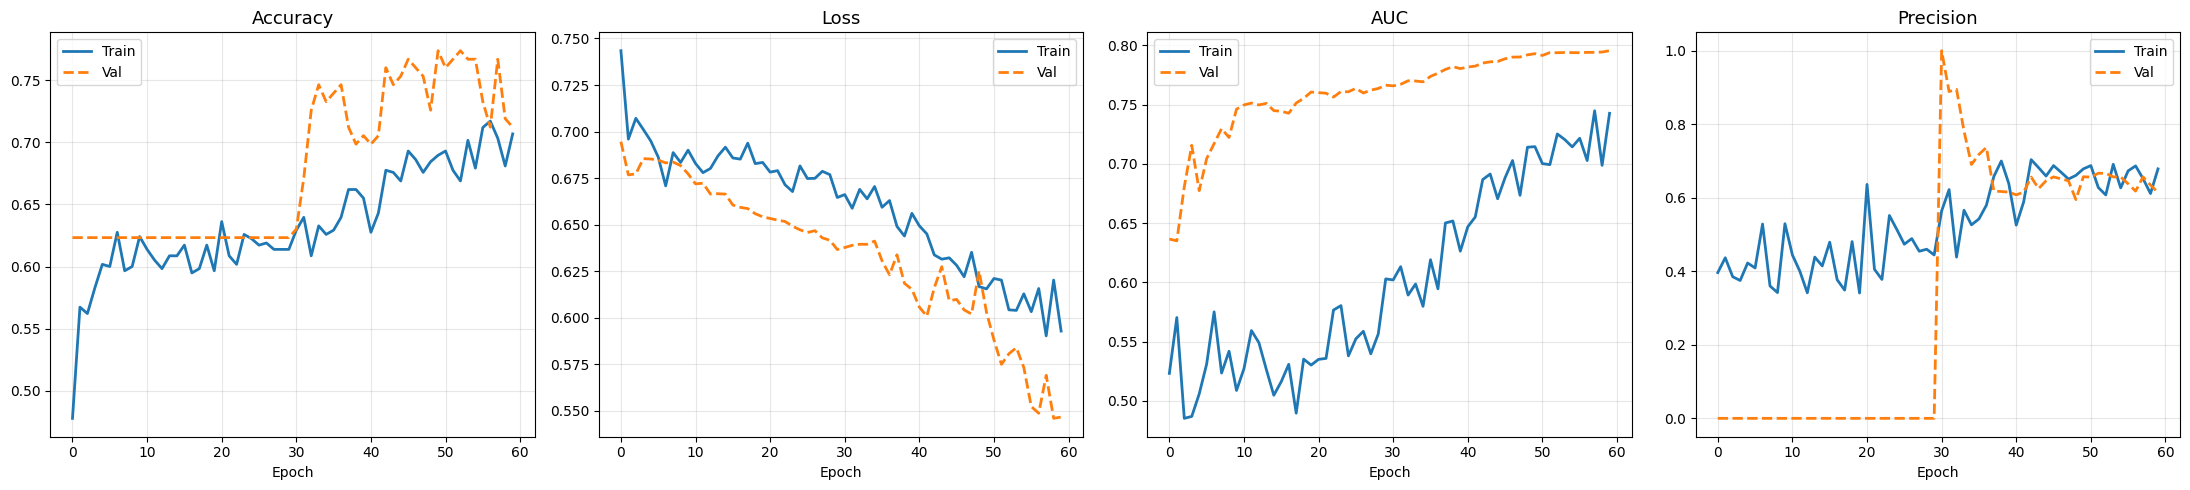


 Done! Model saved to: /kaggle/working/shoplifting_best.keras


In [11]:
# 12. TRAINING CURVES

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['accuracy', 'loss', 'auc', 'precision']
titles  = ['Accuracy', 'Loss', 'AUC', 'Precision']

for ax, key, title in zip(axes, metrics, titles):
    ax.plot(history.history[key],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{key}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

print('\n Done! Model saved to:', SAVE_PATH)